In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.18.0


In [19]:
def handle_categorical_top_k(df, col, k=6):
    top_k = df[col].value_counts().nlargest(k).index
    df[col] = df[col].apply(lambda x: x if x in top_k else "other")
    return df

def load_and_preprocess(train_path, test_path):
    print("Loading UNSW-NB15 dataset...")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    # Drop ID
    for df in (train_df, test_df):
        if "id" in df.columns:
            df.drop("id", axis=1, inplace=True)

    # Combine
    train_df["is_train"] = 1
    test_df["is_train"] = 0
    full_df = pd.concat([train_df, test_df])

    # Log transform skewed numeric features
    skewed = [
        "dur","sbytes","dbytes","sload","dload",
        "spkts","dpkts","sttl","dttl"
    ]
    for col in skewed:
        if col in full_df.columns:
            full_df[col] = np.log1p(full_df[col])

    # Categorical features
    cat_cols = ["proto","service","state"]
    for col in cat_cols:
        if col in full_df.columns:
            full_df = handle_categorical_top_k(full_df, col)

    # One-hot encoding
    full_df = pd.get_dummies(full_df, columns=cat_cols)

    # Fill NaNs
    full_df.fillna(0, inplace=True)

    # Split back
    train_df = full_df[full_df.is_train == 1].drop("is_train", axis=1)
    test_df  = full_df[full_df.is_train == 0].drop("is_train", axis=1)

    print("Features after encoding:", train_df.shape[1])
    return train_df, test_df


In [23]:
train_df, test_df = load_and_preprocess(
    "/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv",
    "/kaggle/input/unsw-nb15/UNSW_NB15_testing-set.csv"
)

X_train = train_df.drop(["label","attack_cat"], axis=1, errors="ignore").values
y_train = train_df["label"].values

X_test  = test_df.drop(["label","attack_cat"], axis=1, errors="ignore").values
y_test  = test_df["label"].values

# Robust scaling (better for network traffic)
scaler = RobustScaler(quantile_range=(5,95))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Clip extreme values
X_train = np.clip(X_train, -5, 5)
X_test  = np.clip(X_test, -5, 5)

# Remove near-constant features
selector = VarianceThreshold(threshold=1e-4)
X_train = selector.fit_transform(X_train)
X_test  = selector.transform(X_test)

print("Final feature count:", X_train.shape[1])



Loading UNSW-NB15 dataset...
Features after encoding: 62
Final feature count: 57


In [25]:
def create_sequences(X, y, seq_len=16, stride=2):
    sequences, labels = [], []

    for i in range(0, len(X) - seq_len + 1, stride):
        seq = X[i:i+seq_len]
        lbl = y[i:i+seq_len]
        sequences.append(seq)
        labels.append(1 if lbl.sum() > seq_len * 0.3 else 0)

    return np.array(sequences), np.array(labels)

SEQ_LEN = 16
STRIDE = 2

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN, STRIDE)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  SEQ_LEN, STRIDE)

# Train only on normal traffic
X_train_normal = X_train_seq[y_train_seq == 0]

X_train_split, X_val_split = train_test_split(
    X_train_normal, test_size=0.2, random_state=42
)

print("Training sequences:", X_train_split.shape)


Training sequences: (14788, 16, 57)


In [27]:
def residual_block(x, filters, dropout=0.2):
    shortcut = x

    x = layers.Conv1D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv1D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.Activation("relu")(x)

def build_model(seq_len, n_features, latent_dim=96):
    inp = Input(shape=(seq_len, n_features))

    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inp)
    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Bidirectional(layers.LSTM(128))(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    x = layers.RepeatVector(seq_len // 4)(latent)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)

    x = layers.UpSampling1D(2)(x)
    x = residual_block(x, 128)

    x = layers.UpSampling1D(2)(x)
    x = residual_block(x, 64)

    out = layers.TimeDistributed(layers.Dense(n_features))(x)

    return Model(inp, out)

def add_noise(x, noise=0.02):
    return x + noise * np.random.normal(size=x.shape)

model = build_model(SEQ_LEN, X_train.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="mse"
)

history = model.fit(
    add_noise(X_train_split),
    X_train_split,
    validation_data=(X_val_split, X_val_split),
    epochs=40,
    batch_size=64,
    callbacks=[
        EarlyStopping(patience=6, restore_best_weights=True),
        ReduceLROnPlateau(patience=4, factor=0.5)
    ],
    verbose=1
)


Epoch 1/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 0.2986 - val_loss: 0.1546 - learning_rate: 5.0000e-04
Epoch 2/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.1430 - val_loss: 0.1250 - learning_rate: 5.0000e-04
Epoch 3/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.1262 - val_loss: 0.1129 - learning_rate: 5.0000e-04
Epoch 4/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.1144 - val_loss: 0.1044 - learning_rate: 5.0000e-04
Epoch 5/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.1052 - val_loss: 0.0969 - learning_rate: 5.0000e-04
Epoch 6/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0985 - val_loss: 0.0922 - learning_rate: 5.0000e-04
Epoch 7/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0931 - val_loss: 0.0859 - learning_rate: 5.0000e-04
Epoch 8/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.0872 - val_loss: 0.0796 - learning_rate: 5.0000e-04
Epoch 9/40
232/232 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0796 - v

In [28]:
def hybrid_error(model, X):
    rec = model.predict(X, verbose=0)
    mse = np.mean((X - rec)**2, axis=(1,2))

    Xf = X.reshape(len(X), -1)
    Rf = rec.reshape(len(rec), -1)

    cos = 1 - np.sum(Xf*Rf, axis=1) / (
        np.linalg.norm(Xf, axis=1) *
        np.linalg.norm(Rf, axis=1) + 1e-9
    )

    mse = (mse - mse.min()) / (mse.max() - mse.min() + 1e-9)
    return 0.7 * mse + 0.3 * cos

errors = hybrid_error(model, X_test_seq)

precision, recall, thresholds = precision_recall_curve(y_test_seq, errors)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
thr = thresholds[np.argmax(f1)]

y_pred = (errors > thr).astype(int)

print("Optimal threshold:", thr)
print(classification_report(y_test_seq, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_seq, errors))


Optimal threshold: 0.08612333534441327
              precision    recall  f1-score   support

           0       0.88      0.78      0.83     24365
           1       0.92      0.96      0.94     63298

    accuracy                           0.91     87663
   macro avg       0.90      0.87      0.88     87663
weighted avg       0.91      0.91      0.91     87663

ROC-AUC: 0.9290039874514459


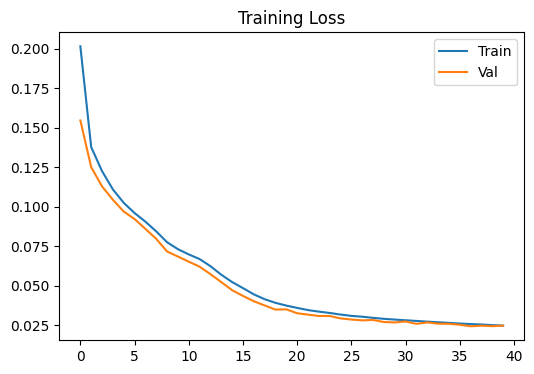

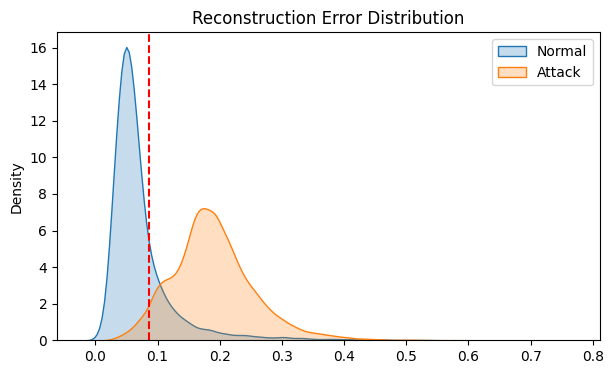

In [29]:
# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.legend()
plt.title("Training Loss")
plt.show()

# Error distribution
plt.figure(figsize=(7,4))
sns.kdeplot(errors[y_test_seq==0], label="Normal", fill=True)
sns.kdeplot(errors[y_test_seq==1], label="Attack", fill=True)
plt.axvline(thr, color="red", linestyle="--")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()
